# Task 4 — House Price Prediction with Linear Regression

**NeuroFive ML Track Week 2: Machine Learning Fundamentals**

In the previous tasks the goal was to answer a yes/no question (did a passenger survive?). That is a **classification** problem.

This task is different: the goal is to predict a **number** the price of a house. Predicting a continuous value is called a **regression** problem, and it is one of the most widely used techniques in industry for pricing, forecasting and valuation.

**What this notebook does**

1. Loads the California Housing dataset (built into scikit-learn).
2. Selects 5 features that are likely to affect house price.
3. Trains a Linear Regression model.
4. Evaluates the model using **RMSE** and **R²**.
5. Plots predicted vs. actual prices.
6. Explains the R² score in plain English.

In [1]:
# Core data libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Make plots a bit larger and cleaner by default
sns.set_theme(style="whitegrid")

## 1. Loading the Dataset

The **California Housing** dataset ships with scikit-learn, so there is no file to download.

Each row is a *census block group* (a small geographic area, roughly 600–3000 people) from the 1990 California census. The target column, `MedHouseVal`, is the **median house value for that block group, expressed in hundreds of thousands of dollars**. So a value of `2.5` means \$250,000.

Setting `as_frame=True` returns the data directly as a pandas DataFrame, which is easier to work with.

In [2]:
# Load the dataset as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)

# housing.frame contains the features AND the target column together
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Dataset description

scikit-learn stores a full text description of the dataset, including what each column means.

In [3]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## 2. Inspecting the Data

Before modelling anything, it is worth checking the size of the dataset, the data types, and whether any values are missing.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20640
Columns: 9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Check for missing values in every column
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
# Summary statistics for every numerical column
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observations

- The dataset has no missing values, so no imputation is required (unlike the Titanic dataset in Tasks 1–3).
- Every column is numerical, so no categorical encoding is needed either.
- `MedHouseVal` appears to be capped at 5.0 (i.e. \$500,000). Any block group worth more than that was recorded as exactly 5.0 in the original census data. This is worth remembering, because the model can never be rewarded for predicting above that ceiling.

## 3. Selecting Features

The task asks for **3–5 features** believed to affect price. The following five were selected:

| Feature | Meaning | Why it might affect price |
|---|---|---|
| `MedInc` | Median income in the block group | Wealthier areas generally have more expensive housing. This is the most intuitive driver of price. |
| `HouseAge` | Median age of the houses | Newer housing stock often sells for more, though location can outweigh this. |
| `AveRooms` | Average number of rooms per household | A proxy for house size — bigger houses cost more. |
| `AveBedrms` | Average number of bedrooms per household | Combined with `AveRooms`, describes the layout and size of the property. |
| `Population` | Population of the block group | A rough signal of how dense or built-up an area is. |

`AveOccup`, `Latitude` and `Longitude` are deliberately left out to keep the model within the 3–5 feature limit requested by the task.

In [8]:
# The features chosen for the model
features = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population'
]

# The value we want to predict
target = 'MedHouseVal'

X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (20640, 5)
Target vector shape: (20640,)


### Checking the relationship between features and price

A correlation heatmap gives a quick sense of which selected features move together with the target. Values close to +1 or -1 indicate a strong linear relationship; values near 0 indicate a weak one.

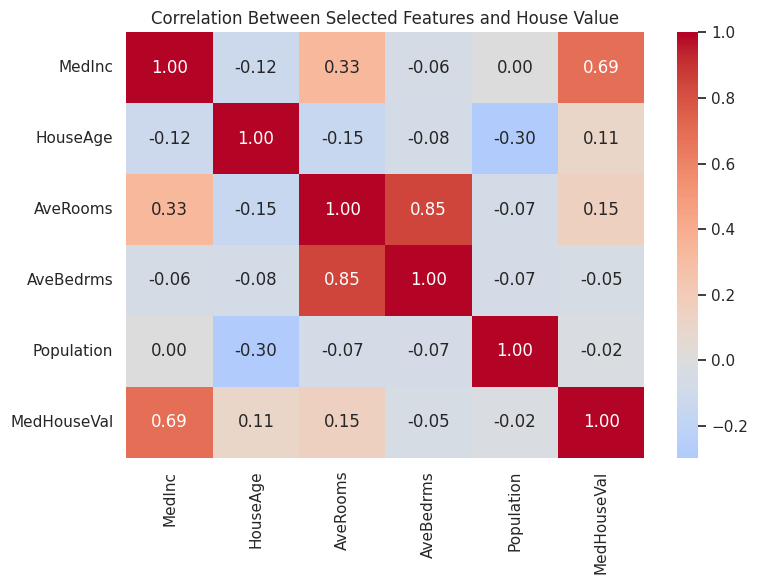

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[features + [target]].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Selected Features and House Value')
plt.tight_layout()
plt.show()

## 4. Splitting the Data into Training and Test Sets

The model is trained on 80% of the data and evaluated on the remaining 20%, which it has never seen.

This matters because a model that is only measured on the data it memorised would look far better than it actually is. The test set is a stand-in for "new, unseen houses".

`random_state=42` makes the split reproducible, so re-running the notebook gives the same result every time.

> Note: `stratify` was used in Task 3 to keep the class balance even. It is not used here because the target is a continuous number, not a set of categories.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


## 5. Training the Linear Regression Model

Linear Regression fits a straight-line relationship of the form:

`predicted_price = intercept + (w1 × MedInc) + (w2 × HouseAge) + (w3 × AveRooms) + (w4 × AveBedrms) + (w5 × Population)`

Training simply means finding the set of weights (`w1 … w5`) and the intercept that make the predictions as close as possible to the actual prices in the training data.

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Model coefficients

Each coefficient shows how much the predicted house value changes when that feature increases by one unit, holding the other features constant. Remember the target is in hundreds of thousands of dollars, so a coefficient of `0.5` means "+\$50,000 per unit increase".

In [12]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coefficients)
print()
print("Intercept:", model.intercept_)

      Feature  Coefficient
0      MedInc     0.544939
1    HouseAge     0.016604
2    AveRooms    -0.223015
3   AveBedrms     1.110462
4  Population     0.000019

Intercept: -0.5508776242031077


## 6. Making Predictions

The trained model is now used to predict house values for the **test set** data it did not see during training.

In [13]:
y_pred = model.predict(X_test)

# Compare the first 10 predictions against the true values
comparison = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': y_pred[:10]
})

print(comparison)

    Actual  Predicted
0  0.47700   1.007350
1  0.45800   1.558125
2  5.00001   2.663990
3  2.18600   2.649040
4  2.78000   1.980511
5  1.58700   2.175262
6  1.98200   2.658564
7  1.57500   2.168058
8  3.40000   2.428479
9  4.46600   4.225005


## 7. Evaluating the Model

Two standard regression metrics are used here.

**RMSE (Root Mean Squared Error)** the typical size of the model's error, measured in the same units as the target. Lower is better. Because larger errors are squared before averaging, RMSE punishes big misses more heavily than small ones.

**R² (R-squared)** the proportion of the variation in house prices that the model manages to explain, on a scale where 1.0 is a perfect fit and 0.0 is no better than always guessing the average price. Higher is better.

In [14]:
# RMSE: take the square root of the mean squared error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# R² score
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.80213318611694
R2 Score: 0.5089947802907753


In [15]:
# Restate the same metrics in dollar terms, since the target is in $100,000s
print("RMSE in dollars: $", round(rmse * 100000, 2))
print("R2 as a percentage:", round(r2 * 100, 2), "%")

RMSE in dollars: $ 80213.32
R2 as a percentage: 50.9 %


### Comparing against a baseline

A useful sanity check is to ask: how well would a model do if it ignored every feature and simply predicted the average house price for every single row?

This "dumb" baseline is exactly what an R² of 0.0 represents. Comparing our RMSE against it shows how much the five features actually contributed.

In [16]:
# Baseline: predict the mean of the training target for every test row
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline RMSE (always predicting the average):", baseline_rmse)
print("Linear Regression RMSE:", rmse)
print("Improvement:", round((1 - rmse / baseline_rmse) * 100, 2), "% lower error than the baseline")

Baseline RMSE (always predicting the average): 1.1448563543099792
Linear Regression RMSE: 0.80213318611694
Improvement: 29.94 % lower error than the baseline


## 8. Predicted vs. Actual Prices

Plotting predictions against the true values is the quickest visual check of model quality.

If the model were perfect, every point would sit exactly on the red diagonal line. The further the cloud of points spreads away from that line, the less accurate the model is.

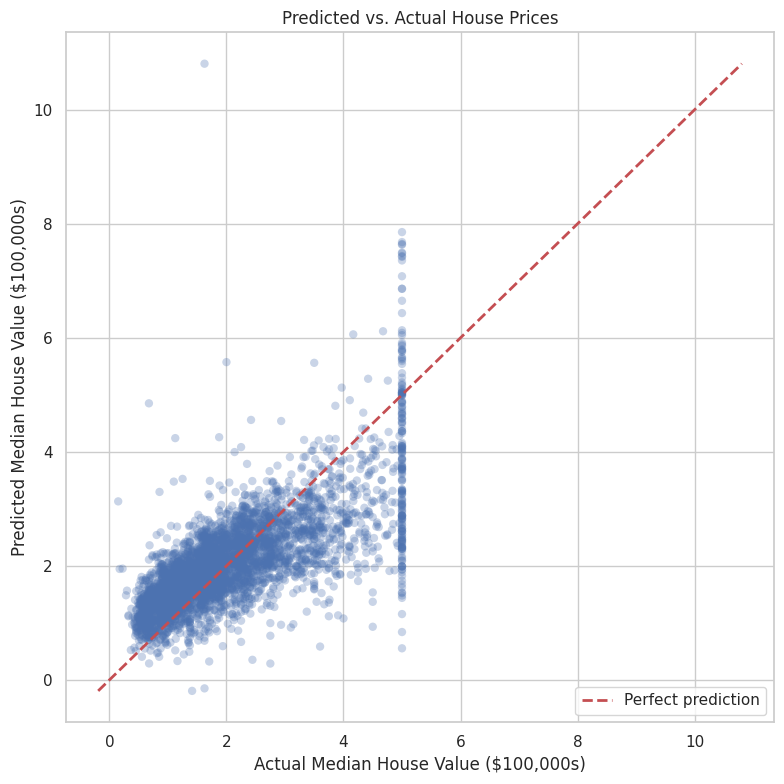

In [17]:
plt.figure(figsize=(8, 8))

# Each point is one test house: true value on x, predicted value on y
plt.scatter(y_test, y_pred, alpha=0.3, edgecolors='none')

# Reference line showing where perfect predictions would fall
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Median House Value ($100,000s)')
plt.ylabel('Predicted Median House Value ($100,000s)')
plt.title('Predicted vs. Actual House Prices')
plt.legend()
plt.tight_layout()
plt.show()

### Residual plot

A residual is simply `actual - predicted`. Plotting residuals against the predictions helps spot systematic mistakes: ideally the points should be scattered randomly around the horizontal zero line with no obvious pattern.

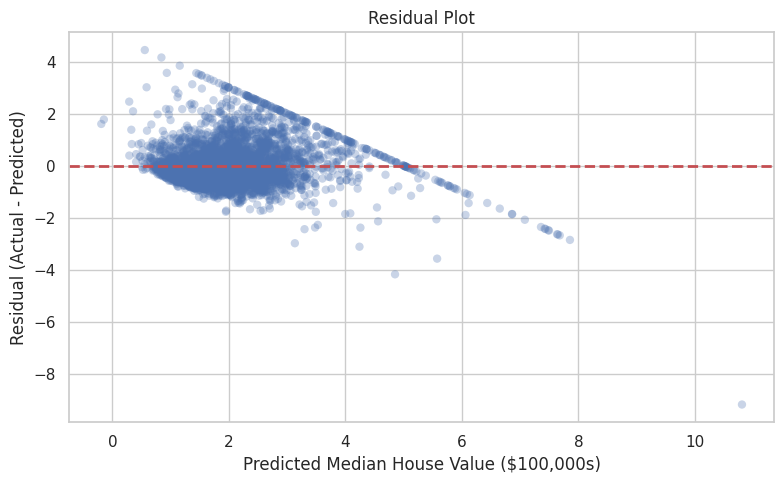

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.3, edgecolors='none')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.xlabel('Predicted Median House Value ($100,000s)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 9. What Does the R² Score Mean? (Plain English)

House prices vary a lot some areas are cheap, some are expensive, and the R² score measures how much of that variation the model has actually managed to explain using the five features it was given. An R² of 1.0 would mean the model predicts every price perfectly, while an R² of 0.0 would mean it is no more useful than simply quoting the average house price for every neighbourhood in California. So if the model scores, for example, 0.50, it is capturing roughly half of what makes one area more expensive than another, and the other half is driven by things the model was never shown most importantly location, since a house near the coast is worth far more than an identical house inland.

In practical terms, this means the model is genuinely picking up a real signal rather than guessing, but it is not accurate enough to price an individual property. The RMSE tells the same story from a different angle: it is the typical amount the prediction is off by, in dollars, and it is best read alongside R² rather than on its own.

The cell below prints these sentences filled in with the **actual numbers produced by this notebook**, so the interpretation always matches the real results rather than a value written by hand.

In [19]:
print("R2 Score:", round(r2, 4))
print()
print(
    "In plain English: this model explains about "
    + str(round(r2 * 100, 1))
    + "% of the variation in California house prices."
)
print(
    "On a typical prediction it is off by roughly $"
    + str(round(rmse * 100000, 2))
    + "."
)
print(
    "The remaining "
    + str(round((1 - r2) * 100, 1))
    + "% of the variation is driven by factors the model was not given, such as location."
)

R2 Score: 0.509

In plain English: this model explains about 50.9% of the variation in California house prices.
On a typical prediction it is off by roughly $80213.32.
The remaining 49.1% of the variation is driven by factors the model was not given, such as location.


## 10. Conclusion

This notebook moved from classification to **regression** by predicting a continuous value - median house price - instead of a yes/no outcome.

**Summary of the workflow**

1. Loaded the built-in California Housing dataset (no download or cleaning required).
2. Selected five features: `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`.
3. Split the data 80/20 into training and test sets.
4. Trained a `LinearRegression` model with scikit-learn.
5. Evaluated it with RMSE and R², and compared it against an average-price baseline.
6. Plotted predicted vs. actual values and inspected the residuals.

**Limitations and possible improvements**

- `Latitude` and `Longitude` were excluded to stay within the 3–5 feature limit, but location is the single biggest driver of California house prices. Adding them would likely improve the score considerably.
- The target is capped at \$500,000, so the model cannot correctly price the most expensive areas.
- Linear Regression assumes a straight-line relationship. Tree-based models such as Random Forest or Gradient Boosting usually perform better on this dataset.